# PCA on clr-transformed 2-mer compositions

This notebook represents each sequence by its 2-mer composition, applies a clr transform, and projects the data with PCA. This is a feature-based alternative to direct edit-distance embeddings.

## Inputs

All notebooks use the same FASTA inputs bundled in `sequenceTols`: `example_vertices.fasta` for the three references and `example_queries.fasta` for the query sequences. You can replace those paths in the first code cell with your own FASTA files.

In [1]:
from pathlib import Path
import csv
import math
from pprint import pprint

import matplotlib.pyplot as plt
import numpy as np

REFERENCES_FASTA = Path("example_vertices.fasta")
QUERIES_FASTA = Path("example_queries.fasta")
OUTPUT_PREFIX = Path("notebook_output")


def parse_fasta(path: Path):
    records = []
    header = None
    chunks = []
    with path.open() as handle:
        for raw_line in handle:
            line = raw_line.strip()
            if not line:
                continue
            if line.startswith(">"):
                if header is not None:
                    records.append((header, "".join(chunks).upper()))
                header = line[1:].strip() or f"seq_{len(records) + 1}"
                chunks = []
            else:
                chunks.append(line)
    if header is not None:
        records.append((header, "".join(chunks).upper()))
    if not records:
        raise ValueError(f"No FASTA records found in {path}")
    return records


def normalized_hamming(seq_a: str, seq_b: str) -> float:
    if len(seq_a) != len(seq_b):
        raise ValueError("Hamming distance requires equal-length sequences.")
    if len(seq_a) == 0:
        return 0.0
    mismatches = sum(char_a != char_b for char_a, char_b in zip(seq_a, seq_b))
    return mismatches / len(seq_a)


def levenshtein_distance(seq_a: str, seq_b: str) -> int:
    if len(seq_a) < len(seq_b):
        seq_a, seq_b = seq_b, seq_a
    previous = list(range(len(seq_b) + 1))
    for i, char_a in enumerate(seq_a, start=1):
        current = [i]
        for j, char_b in enumerate(seq_b, start=1):
            insert_cost = current[j - 1] + 1
            delete_cost = previous[j] + 1
            substitute_cost = previous[j - 1] + (char_a != char_b)
            current.append(min(insert_cost, delete_cost, substitute_cost))
        previous = current
    return previous[-1]


def normalized_levenshtein(seq_a: str, seq_b: str) -> float:
    scale = max(len(seq_a), len(seq_b))
    if scale == 0:
        return 0.0
    return levenshtein_distance(seq_a, seq_b) / scale


def affinity_linear(distance: float) -> float:
    return max(0.0, 1.0 - distance)


def close_affinities(affinities):
    affinities = np.asarray(affinities, dtype=float)
    total = float(affinities.sum())
    if total <= 0.0:
        return np.full(3, 1.0 / 3.0)
    return affinities / total


def barycentric_to_cartesian(lambdas):
    vertices = np.array([
        [0.0, 0.0],
        [1.0, 0.0],
        [0.5, math.sqrt(3.0) / 2.0],
    ])
    return np.asarray(lambdas, dtype=float) @ vertices


def write_csv(path: Path, rows, fieldnames):
    with path.open("w", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

import itertools

DNA_ALPHABET = "ACGT"

def all_kmers(alphabet, k):
    return ["".join(parts) for parts in itertools.product(alphabet, repeat=k)]


def kmer_composition(sequence, k=2, pseudocount=0.5):
    kmers = all_kmers(DNA_ALPHABET, k)
    index = {kmer: i for i, kmer in enumerate(kmers)}
    counts = np.full(len(kmers), pseudocount, dtype=float)
    valid = set(DNA_ALPHABET)
    for start in range(len(sequence) - k + 1):
        kmer = sequence[start:start + k]
        if set(kmer) <= valid:
            counts[index[kmer]] += 1.0
    return counts / counts.sum(), kmers


def clr_transform(composition):
    logs = np.log(composition)
    return logs - logs.mean()


def pca_two_components(matrix):
    centered = matrix - matrix.mean(axis=0, keepdims=True)
    _, singular_values, vt = np.linalg.svd(centered, full_matrices=False)
    coordinates = centered @ vt[:2].T
    variance = (singular_values ** 2) / max(matrix.shape[0] - 1, 1)
    explained = variance[:2] / variance.sum()
    return coordinates, explained


## Mathematical formulation

This notebook does not start from edit distances. Instead, each sequence $S$ is represented by its $k$-mer composition.

If the alphabet is $\mathcal{A}$ and the notebook uses $k=2$, then the number of possible features is
\[
D=|\mathcal{A}|^k.
\]
If $n_j(S)$ is the count of the $j$-th $k$-mer and $\alpha>0$ is a pseudocount, then
\[
\tilde n_j(S)=n_j(S)+\alpha,
\qquad
x_j(S)=\frac{\tilde n_j(S)}{\sum_{m=1}^D \tilde n_m(S)}.
\]
Thus
\[
\mathbf{x}(S)=\big(x_1(S),\dots,x_D(S)\big)
\]
is a compositional vector in the simplex.

To map this into a Euclidean coordinate system, the notebook applies the centered log-ratio transform
\[
\operatorname{clr}(\mathbf{x})=
\left(
\log\frac{x_1}{g(\mathbf{x})},
\dots,
\log\frac{x_D}{g(\mathbf{x})}
\right),
\]
where
\[
g(\mathbf{x})=\left(\prod_{j=1}^D x_j\right)^{1/D}
\]
is the geometric mean of the parts.

If $Z$ is the matrix whose rows are the clr vectors for all sequences, then after centering the columns,
\[
Z_c=Z-\mathbf{1}\bar{\mathbf{z}}^\top,
\]
PCA is obtained from the singular value decomposition
\[
Z_c=U\Sigma V^\top.
\]
The first two principal component score coordinates are
\[
T_2=Z_cV_2.
\]

## Interpretation and limitations

This is a **feature-based compositional ordination**, not an edit-distance embedding.

It is useful when sequence composition or motif-like content is the main signal, but its interpretation differs from MDS and from the reference-based notebooks:

- it depends on the choice of alphabet and $k$,
- it depends on the pseudocount and clr transform,
- PCA emphasizes directions of largest variance in feature space, not direct pairwise sequence distances,
- it can outperform alignment-based methods when alignments are unstable or when local compositional signal matters more than sitewise homology.

This notebook is mathematically the closest one in the folder to classical compositional data analysis.

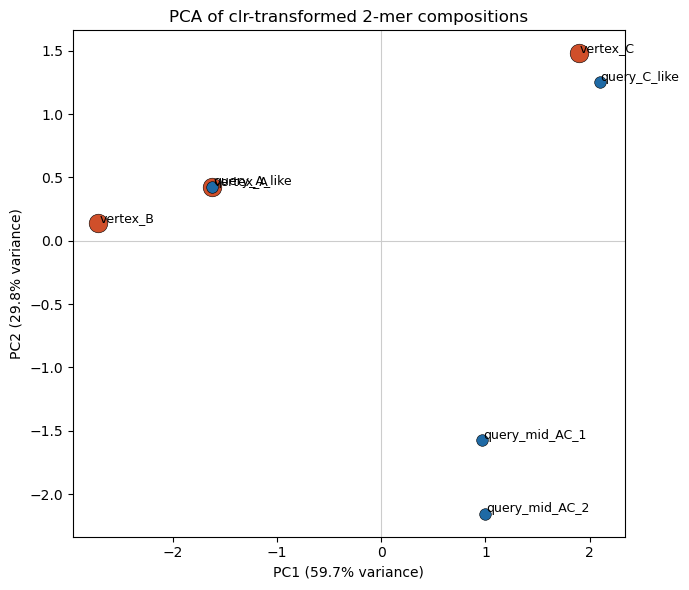

Saved CSV: notebook_output_kmer_pca_coordinates.csv
Saved plot: notebook_output_kmer_pca.png
Explained variance: [0.59674587 0.29826268]
[{'pc1': -1.6185672036273044,
  'pc2': 0.4275344855446719,
  'sequence_id': 'vertex_A'},
 {'pc1': -2.7153574630922988,
  'pc2': 0.1393089703629699,
  'sequence_id': 'vertex_B'},
 {'pc1': 1.8952594992051301,
  'pc2': 1.4795981521695407,
  'sequence_id': 'vertex_C'},
 {'pc1': -1.6201671579320402,
  'pc2': 0.42718452641625226,
  'sequence_id': 'query_A_like'},
 {'pc1': 0.9673261915912512,
  'pc2': -1.5720530177315837,
  'sequence_id': 'query_mid_AC_1'},
 {'pc1': 0.996368189226694,
  'pc2': -2.1549218387289653,
  'sequence_id': 'query_mid_AC_2'},
 {'pc1': 2.0951379446285676,
  'pc2': 1.2533487219671138,
  'sequence_id': 'query_C_like'}]


In [2]:
reference_records = parse_fasta(REFERENCES_FASTA)
query_records = parse_fasta(QUERIES_FASTA)
all_records = reference_records + query_records
labels = [record[0] for record in all_records]

vectors = []
for _, sequence in all_records:
    composition, kmers = kmer_composition(sequence, k=2, pseudocount=0.5)
    vectors.append(clr_transform(composition))

matrix = np.vstack(vectors)
coordinates, explained = pca_two_components(matrix)
rows = []
for label, coord in zip(labels, coordinates):
    rows.append({
        "sequence_id": label,
        "pc1": float(coord[0]),
        "pc2": float(coord[1]),
    })

output_csv = Path(f"{OUTPUT_PREFIX.name}_kmer_pca_coordinates.csv")
write_csv(output_csv, rows, ["sequence_id", "pc1", "pc2"])

fig, ax = plt.subplots(figsize=(7, 6))
for idx, (label, coord) in enumerate(zip(labels, coordinates)):
    color = "#d04f2a" if idx < 3 else "#1f6aa5"
    size = 180 if idx < 3 else 70
    ax.scatter(coord[0], coord[1], color=color, s=size, edgecolor="black", linewidth=0.4)
    ax.text(coord[0] + 0.01, coord[1] + 0.01, label, fontsize=9)

ax.set_title("PCA of clr-transformed 2-mer compositions")
ax.set_xlabel(f"PC1 ({explained[0] * 100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({explained[1] * 100:.1f}% variance)")
ax.axhline(0.0, color="#cccccc", linewidth=0.8)
ax.axvline(0.0, color="#cccccc", linewidth=0.8)
fig.tight_layout()
output_png = Path(f"{OUTPUT_PREFIX.name}_kmer_pca.png")
fig.savefig(output_png, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved CSV: {output_csv}")
print(f"Saved plot: {output_png}")
print("Explained variance:", explained)
pprint(rows)
